In [1]:
import pandas as pd
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import MinMaxScaler
from sentence_transformers import SentenceTransformer

# === Load CSVs ===
sentiment_df = pd.read_csv("sentiment_replies.csv")
topic_df = pd.read_csv("topic.csv")

# === Clean sentiment_replies.csv ===
sentiment_df['dateTime'] = (
    sentiment_df['dateTime'].astype(str).str.replace('»', '', regex=False).str.strip()
)
sentiment_df['dateTime'] = pd.to_datetime(sentiment_df['dateTime'], format='mixed')

sentiment_df['postcount'] = (
    sentiment_df['postcount'].astype(str)
    .str.extract(r'(\d[\d,]*)')[0]
    .str.replace(',', '', regex=False)
    .astype(float)
)

sentiment_df['author'] = sentiment_df['author'].astype(str).str.strip().str.lower()
sentiment_df['member group'] = sentiment_df['member group'].astype(str).str.strip().str.lower()

sentiment_df['reply_index'] = (
    sentiment_df['threadDetails'].astype(str)
    .str.extract(r'Reply\s+#(\d+)', expand=False)
    .fillna(0).astype(int)
)

sentiment_columns = ['pos', 'neg', 'neu', 'compound', 'textblob_sentiment']
for col in sentiment_columns:
    sentiment_df[col] = pd.to_numeric(sentiment_df[col], errors='coerce')

sentiment_df_cleaned = sentiment_df.dropna(subset=['dateTime', 'postId'])
sentiment_df_cleaned = sentiment_df_cleaned.drop_duplicates(subset=['postId'])
sentiment_df_cleaned.reset_index(drop=True, inplace=True)

# === Clean topic.csv ===
topic_df['views'] = (
    topic_df['views'].astype(str)
    .str.replace(r'\s+', '', regex=True)
    .str.replace(r'\D', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

topic_df['datePost'] = (
    topic_df['datePost'].astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
topic_df['datePost'] = pd.to_datetime(topic_df['datePost'], format='mixed')

topic_df['replies'] = pd.to_numeric(topic_df['replies'], errors='coerce').fillna(0).astype(int)

for col in ['topic', 'startedBy', 'latestBy']:
    topic_df[col] = topic_df[col].astype(str).str.strip().str.lower().replace('nan', 'unknown')

topic_df_cleaned = topic_df.dropna(subset=['id', 'datePost']).drop_duplicates(subset=['id']).reset_index(drop=True)

# === Merge ===
merged_df = sentiment_df_cleaned.merge(
    topic_df_cleaned, left_on="connecting_id", right_on="id",
    suffixes=('_reply', '_topic')
)

merged_df = merged_df.sort_values(by=["connecting_id", "dateTime"]).reset_index(drop=True)
merged_df['delta_t'] = merged_df.groupby('connecting_id')['dateTime'].diff().dt.total_seconds() / 3600
merged_df['delta_t'] = merged_df['delta_t'].fillna(0)

# === Create feature_df with replyMess and label ===
feature_df = merged_df[[
    'connecting_id', 'postId', 'dateTime', 'replyMess', 'delta_t',
    'compound', 'textblob_sentiment', 'reply_index',
    'postcount', 'views', 'replies', 'topic'
]].copy()

# === Add label (1 if next reply is within 24h) ===
feature_df['label'] = 0
grouped = feature_df.groupby("connecting_id")

for thread_id, group in grouped:
    times = group['dateTime'].values
    indices = group.index.values
    for i in range(len(times) - 1):
        current_time = times[i]
        future_times = times[i+1:]
        time_gaps = (future_times - current_time) / np.timedelta64(1, 'h')
        if any(time_gaps <= 24):
            feature_df.loc[indices[i], 'label'] = 1

# === Step 1: Generate SBERT embeddings for replyMess ===
print("Generating SBERT embeddings...")
sbert = SentenceTransformer('all-MiniLM-L6-v2')
reply_texts = feature_df['replyMess'].astype(str).tolist()
reply_embeddings = sbert.encode(reply_texts, show_progress_bar=True)  # shape: (num_posts, 384)

# === Step 2: Normalize numeric features ===
feature_cols = ['delta_t', 'compound', 'textblob_sentiment', 'reply_index', 'postcount', 'views', 'replies']
scaler = MinMaxScaler()
feature_df[feature_cols] = scaler.fit_transform(feature_df[feature_cols])
X_structured = feature_df[feature_cols].values  # shape: (num_posts, 7)

# === Step 3: Concatenate structured + SBERT embeddings ===
X_combined = np.hstack((X_structured, reply_embeddings))  # shape: (num_posts, 391)

# === Step 4: Group sequences and labels by thread ===
sequences = []
label_sequences = []

for thread_id, group in feature_df.groupby("connecting_id"):
    indices = group.index
    features_tensor = torch.tensor(X_combined[indices], dtype=torch.float32)
    labels_tensor = torch.tensor(group['label'].values, dtype=torch.float32)
    sequences.append(features_tensor)
    label_sequences.append(labels_tensor)

# === Step 5: Pad sequences ===
padded_inputs = pad_sequence(sequences, batch_first=True)      # (num_threads, max_seq_len, 391)
padded_labels = pad_sequence(label_sequences, batch_first=True)  # (num_threads, max_seq_len)

# === Done ===
print("✅ Final SBERT input shape:", padded_inputs.shape)
print("✅ Final label shape:", padded_labels.shape)


Generating SBERT embeddings...


Batches:   0%|          | 0/217 [00:00<?, ?it/s]

✅ Final SBERT input shape: torch.Size([730, 50, 391])
✅ Final label shape: torch.Size([730, 50])


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

class DecayedAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.u = nn.Parameter(torch.randn(hidden_dim))
        self.w = nn.Parameter(torch.tensor(1.0))

    def forward(self, h, times, mask=None):
        B, T, H = h.shape
        time_diffs = times.unsqueeze(2) - times.unsqueeze(1)
        gamma = torch.exp(-self.w * time_diffs.clamp(min=0))
        u_proj = torch.tanh(torch.matmul(h, self.u))
        e = u_proj.unsqueeze(2) * gamma
        if mask is not None:
            mask = mask.unsqueeze(1).expand(B, T, T)
            e = e.masked_fill(~mask, float('-inf'))
        attn_weights = F.softmax(e, dim=2)
        context = torch.bmm(attn_weights, h)
        return context, attn_weights

class BehavioralPointProcessModel(nn.Module):
    def __init__(self, input_dim=391, hidden_dim=128):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.attn_time = DecayedAttention(hidden_dim)
        self.attn_reply = DecayedAttention(hidden_dim)
        self.time_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Softplus())
        self.reply_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Sigmoid())

    def forward(self, x, times, mask):
        h, _ = self.gru(x)
        s_time, attn_time = self.attn_time(h, times, mask)
        s_reply, attn_reply = self.attn_reply(h, times, mask)
        lambda_t = self.time_head(s_time).squeeze(-1)
        pi_reply = self.reply_head(s_reply).squeeze(-1)
        return {'lambda': lambda_t, 'reply_prob': pi_reply, 'attn_time': attn_time, 'attn_reply': attn_reply}

# ==== BUILD PADDED TIMES FROM FEATURE_DF ====

def build_padded_times(feature_df):
    time_sequences = []
    for _, group in feature_df.groupby("connecting_id"):
        times = torch.tensor(group['delta_t'].values, dtype=torch.float32)
        time_sequences.append(times)
    return pad_sequence(time_sequences, batch_first=True)

# ==== TRAINING LOOP WITH MASKING, METRICS, EARLY STOPPING ====

def train_model(model, X_train, y_train, t_train, X_val, y_val, t_val, num_epochs=20, lr=1e-3, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    mask_train = (X_train.sum(dim=-1) != 0)
    mask_val = (X_val.sum(dim=-1) != 0)

    X_train, y_train, t_train, mask_train = X_train.to(device), y_train.to(device), t_train.to(device), mask_train.to(device)
    X_val, y_val, t_val, mask_val = X_val.to(device), y_val.to(device), t_val.to(device), mask_val.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)
    loss_fn = nn.BCELoss(reduction='none')

    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        output = model(X_train, t_train, mask_train)
        preds = output['reply_prob']
        loss_matrix = loss_fn(preds, y_train)
        masked_loss = (loss_matrix * mask_train).sum() / mask_train.sum()
        masked_loss.backward()
        optimizer.step()
        scheduler.step(masked_loss)

        model.eval()
        with torch.no_grad():
            val_output = model(X_val, t_val, mask_val)
            val_preds = val_output['reply_prob']
            val_loss_matrix = loss_fn(val_preds, y_val)
            val_loss = (val_loss_matrix * mask_val).sum() / mask_val.sum()

            val_pred_labels = (val_preds > 0.5).float()
            preds_flat = val_pred_labels[mask_val].cpu().numpy()
            labels_flat = y_val[mask_val].cpu().numpy()
            precision, recall, f1, _ = precision_recall_fscore_support(labels_flat, preds_flat, average='binary', zero_division=0)

        print(f"Epoch {epoch+1}: Train Loss = {masked_loss.item():.4f}  Val Loss = {val_loss.item():.4f}")
        print(f"  Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")

        if val_loss.item() < best_loss:
            best_loss = val_loss.item()
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

# ==== VISUALIZE ATTENTION ====

def visualize_attention(model, thread_idx, input_tensor, time_tensor, mask_tensor):
    model.eval()
    with torch.no_grad():
        output = model(input_tensor, time_tensor, mask_tensor)
        attn = output['attn_reply'][thread_idx]  # (T, T)
        plt.figure(figsize=(10, 6))
        sns.heatmap(attn.cpu().numpy(), cmap='viridis')
        plt.title(f'Attention Weights for Thread {thread_idx}')
        plt.xlabel('Attended Posts')
        plt.ylabel('Query Posts')
        plt.show()


In [12]:
from torch.nn.utils.rnn import pad_sequence
import torch

# Group delta_t by thread
time_sequences = []

for _, group in feature_df.groupby("connecting_id"):
    times = torch.tensor(group['delta_t'].values, dtype=torch.float32)
    time_sequences.append(times)

padded_times = pad_sequence(time_sequences, batch_first=True)

In [15]:
from sklearn.model_selection import train_test_split
import numpy as np

idx = np.arange(padded_inputs.shape[0])
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42)

X_train, X_val = padded_inputs[train_idx], padded_inputs[val_idx]
y_train, y_val = padded_labels[train_idx], padded_labels[val_idx]
t_train, t_val = padded_times[train_idx], padded_times[val_idx]


In [17]:
model1 = BehavioralPointProcessModel()
train_model(model1, X_train, y_train, t_train, X_val, y_val, t_val, num_epochs=100, lr=1e-1, patience=10)


C:\Users\shubb\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Loss = 0.6903  Val Loss = 2.0238
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 2: Train Loss = 1.8255  Val Loss = 2.8573
  Precision: 0.6000  Recall: 0.0036  F1: 0.0071
Epoch 3: Train Loss = 3.1648  Val Loss = 0.7369
  Precision: 0.6574  Recall: 0.7620  F1: 0.7058
Epoch 4: Train Loss = 0.7553  Val Loss = 0.6349
  Precision: 0.6607  Recall: 0.9689  F1: 0.7856
Epoch 5: Train Loss = 0.5967  Val Loss = 0.7506
  Precision: 0.6533  Recall: 0.9916  F1: 0.7876
Epoch 6: Train Loss = 0.6951  Val Loss = 0.8487
  Precision: 0.6516  Recall: 1.0000  F1: 0.7891
Epoch 7: Train Loss = 0.7852  Val Loss = 0.8174
  Precision: 0.6511  Recall: 0.9844  F1: 0.7838
Epoch 8: Train Loss = 0.7612  Val Loss = 0.7036
  Precision: 0.6555  Recall: 0.9557  F1: 0.7776
Epoch 9: Train Loss = 0.6657  Val Loss = 0.6744
  Precision: 0.6625  Recall: 0.8876  F1: 0.7587
Epoch 10: Train Loss = 0.6470  Val Loss = 0.6844
  Precision: 0.6796  Recall: 0.7356  F1: 0.7065
Epoch 11: Train Loss = 0.6624  Val Loss

In [19]:
model2 = BehavioralPointProcessModel()
train_model(model2, X_train, y_train, t_train, X_val, y_val, t_val, num_epochs=100, lr=1e-2, patience=10)

C:\Users\shubb\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Loss = 0.6956  Val Loss = 0.6415
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 2: Train Loss = 0.6055  Val Loss = 0.6995
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 3: Train Loss = 0.6286  Val Loss = 0.6422
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 4: Train Loss = 0.5890  Val Loss = 0.6363
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 5: Train Loss = 0.5906  Val Loss = 0.6382
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 6: Train Loss = 0.5905  Val Loss = 0.6341
  Precision: 0.6516  Recall: 0.9976  F1: 0.7883
Epoch 7: Train Loss = 0.5798  Val Loss = 0.6290
  Precision: 0.6523  Recall: 0.9964  F1: 0.7885
Epoch 8: Train Loss = 0.5686  Val Loss = 0.6285
  Precision: 0.6523  Recall: 0.9964  F1: 0.7885
Epoch 9: Train Loss = 0.5642  Val Loss = 0.6316
  Precision: 0.6569  Recall: 0.9892  F1: 0.7895
Epoch 10: Train Loss = 0.5649  Val Loss = 0.6317
  Precision: 0.6592  Recall: 0.9809  F1: 0.7885
Epoch 11: Train Loss = 0.5636  Val Loss

In [20]:
model3 = BehavioralPointProcessModel()
train_model(model3, X_train, y_train, t_train, X_val, y_val, t_val, num_epochs=100, lr=1e-3, patience=10)


Epoch 1: Train Loss = 0.6945  Val Loss = 0.6871
  Precision: 0.6583  Recall: 0.9773  F1: 0.7867
Epoch 2: Train Loss = 0.6782  Val Loss = 0.6768
  Precision: 0.6516  Recall: 1.0000  F1: 0.7891
Epoch 3: Train Loss = 0.6631  Val Loss = 0.6676
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 4: Train Loss = 0.6491  Val Loss = 0.6593
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 5: Train Loss = 0.6359  Val Loss = 0.6522
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 6: Train Loss = 0.6237  Val Loss = 0.6463
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887


C:\Users\shubb\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 7: Train Loss = 0.6126  Val Loss = 0.6420
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 8: Train Loss = 0.6028  Val Loss = 0.6397
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 9: Train Loss = 0.5947  Val Loss = 0.6400
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 10: Train Loss = 0.5890  Val Loss = 0.6435
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 11: Train Loss = 0.5863  Val Loss = 0.6501
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 12: Train Loss = 0.5872  Val Loss = 0.6578
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 13: Train Loss = 0.5904  Val Loss = 0.6622
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 14: Train Loss = 0.5925  Val Loss = 0.6612
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 15: Train Loss = 0.5914  Val Loss = 0.6587
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 16: Train Loss = 0.5895  Val Loss = 0.6550
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 17: Train Loss = 0.5868  Va

In [24]:
model4 = BehavioralPointProcessModel()
train_model(model4, X_train, y_train, t_train, X_val, y_val, t_val, num_epochs=100, lr=1e-4, patience=10)


C:\Users\shubb\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Loss = 0.6785  Val Loss = 0.6823
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 2: Train Loss = 0.6768  Val Loss = 0.6813
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 3: Train Loss = 0.6751  Val Loss = 0.6802
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 4: Train Loss = 0.6735  Val Loss = 0.6791
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 5: Train Loss = 0.6719  Val Loss = 0.6781
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 6: Train Loss = 0.6703  Val Loss = 0.6770
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 7: Train Loss = 0.6687  Val Loss = 0.6760
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 8: Train Loss = 0.6671  Val Loss = 0.6750
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 9: Train Loss = 0.6655  Val Loss = 0.6740
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 10: Train Loss = 0.6640  Val Loss = 0.6730
  Precision: 0.6511  Recall: 1.0000  F1: 0.7887
Epoch 11: Train Loss = 0.6625  Val Loss

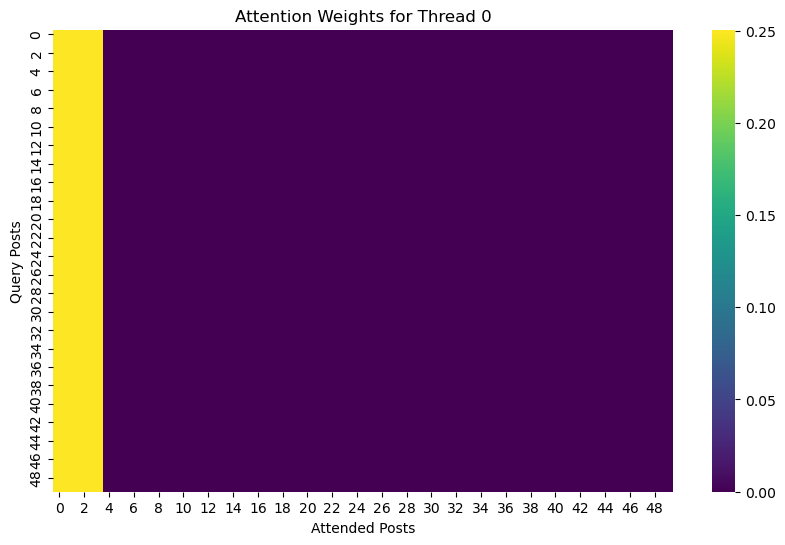

In [28]:
device = next(model4.parameters()).device  # Get model's device

visualize_attention(
    model4,
    thread_idx=0,
    input_tensor=X_val.to(device),
    time_tensor=t_val.to(device),
    mask_tensor=(X_val.sum(-1) != 0).to(device)
)
